In [1]:
# works with kernel xfel (202501)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches # to draw rectangles and circles for q-bins
import matplotlib.cm as cm # to create a colormap to be assigned to the q-bins
from matplotlib.colors import LogNorm
import scipy
import time
import datetime as dt
import h5py
import hdf5plugin
from pathlib import Path
import re # for regular expressions

#%matplotlib widget
%load_ext autoreload

In [2]:
# load functions from python file
import autoXPCSatP10_utils as autoXPCS

%autoreload 2

ModuleNotFoundError: No module named 'pyFAI'

# INPUT

In [7]:
dir_beamtime = Path('/asap3/petra3/gpfs/p10/2025/data/11020993/')
sample_name = 'm035_starch'
scans = np.arange(10,12)
detector = 'e4m'
skip_frames_start = 1
precision_SAXS = 600
average_over_frames_SAXS = 100   # if you want to have SAXS slices give here the number of frames to average over for each slice,
                                # if 0 is put in SAXS slices are ignored ond only the SAXS over all frames is calculated

# mask
dir_mask = dir_beamtime / 'processed/Sebastian/'
filename_mask = 'crude_mask.npy' 

# temperarure
process_temp_data = True
path_to_temp_file = dir_beamtime / 'processed/Sebastian/20250524180435_USAXS.txt' #20250521232447_SAXS.txt'
path_to_temp_file = dir_beamtime / 'processed/Sebastian/20250521232447_SAXS.txt'
# figure show parameters
show_processing_figures = True
plot_max_incoherent_img = 0.05

# saving parameters
save_results = True
dir_general_saving = dir_beamtime / 'processed/Sebastian/Results_AutomaticPython/'

In [8]:
# define the q-partitions
q_centers = np.arange(0.1,1,0.05) * 1e9
q_widths = 0.05*np.ones(len(q_centers)) * 1e9
q_rings = autoXPCS.Q_Rings(q_radii=q_centers, q_widths=q_widths)

In [20]:
# for processing with Randeers q-partitions use the following cell:
#q_partitions_Randeer = np.load(dir_beamtime / 'processed/Freddy/q_partitions_Randeer_ferritin.npy')
#q_centers = q_partitions_Randeer[:,0]
#q_widths = q_partitions_Randeer[:,1]
#q_rings = autoXPCS.Q_Rings(q_radii=q_centers, q_widths=q_widths)

# short overview/search over experiments in raw folder

In [21]:
raw_path = dir_beamtime / 'raw/'

for i in sorted(raw_path.glob('m035*')): #string with search term, * as variable(s)
    #if f'{i.name[-6:]}' in [f'_{j:05d}' for j in range(1000)]: continue # outcomment to get scan numbers
    print (i.name)

m035_starch
m035_starch_00001
m035_starch_00002
m035_starch_00003
m035_starch_00004
m035_starch_00005
m035_starch_00007
m035_starch_00008
m035_starch_00009
m035_starch_00010
m035_starch_00011
m035_starch_00012
m035_starch_00013
m035_starch_00014
m035_starch_00015
m035_starch_00016
m035_starch_00017
m035_starch_00018


# Processing

In [9]:
sample = autoXPCS.Sample(directory_beamtime=dir_beamtime, sample_name=sample_name)
mask = autoXPCS.Mask(directory_mask=dir_mask, filename_mask=filename_mask)
experimental_parameters = autoXPCS.Experimental_Parameters() # at this point, only an instance is required for initialization of the scan.
#  With the scan instance initialized, the parameters can be updated.
q_partitions = autoXPCS.Q_Partitions()

Results will be saved under:
/asap3/petra3/gpfs/p10/2025/data/11020993/processed/Sebastian/Results_AutomaticPython/m035_starch_00010_01.


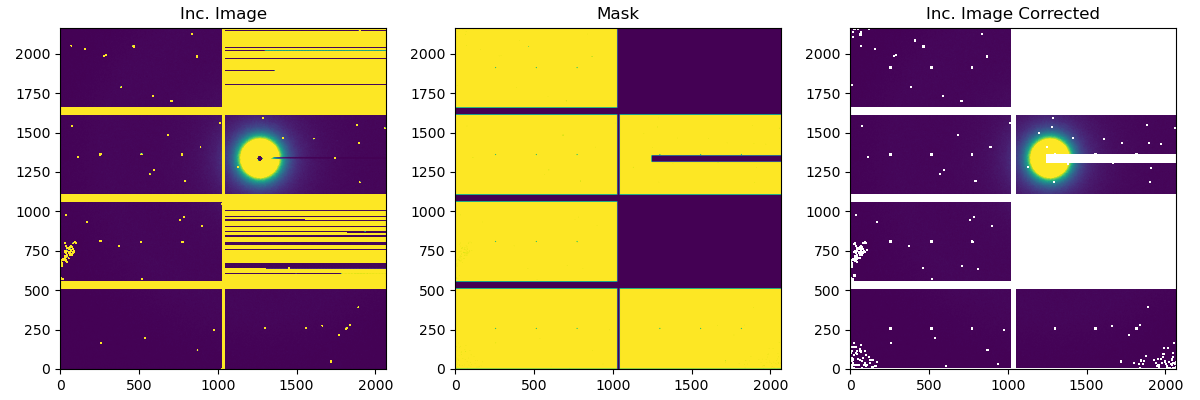

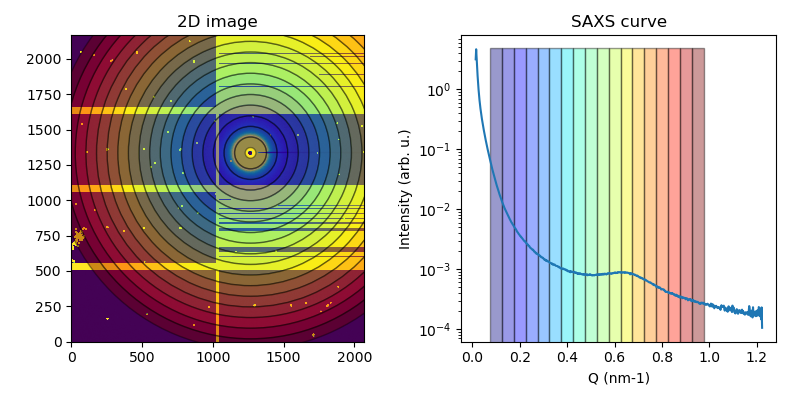

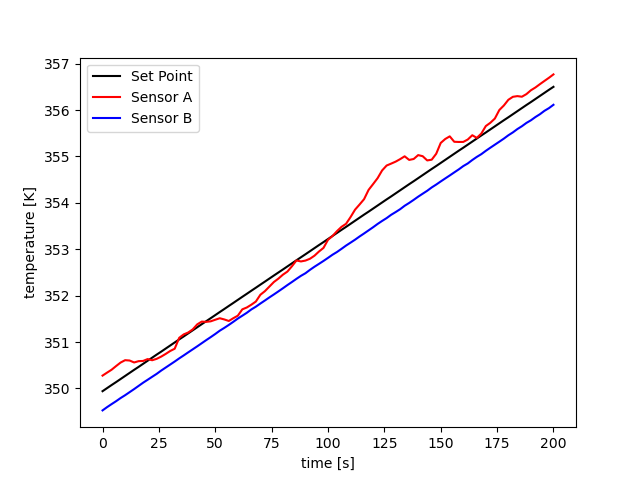

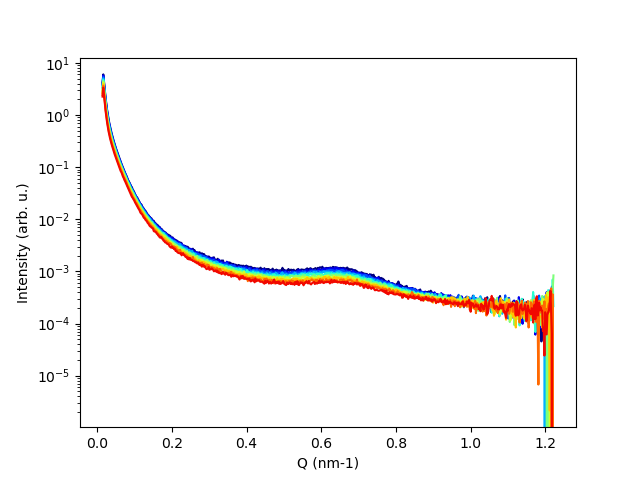

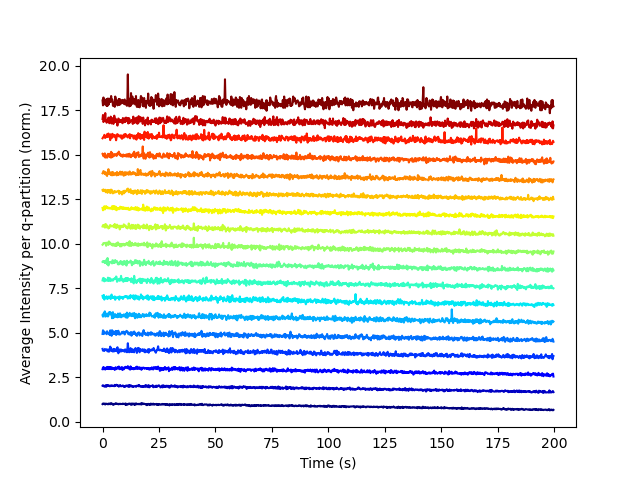

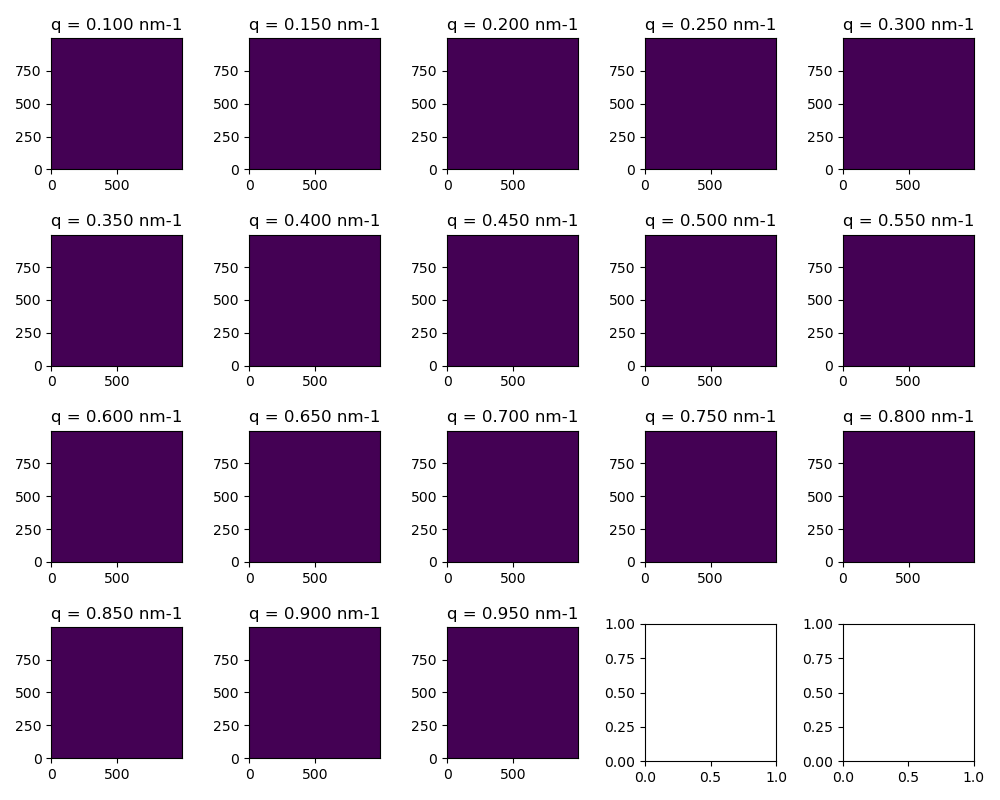

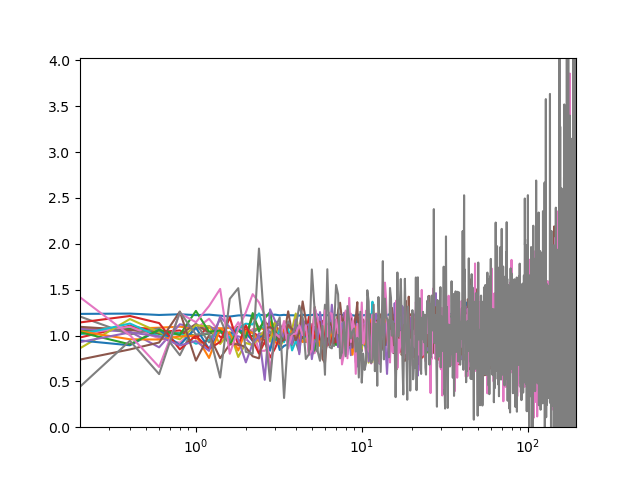

Took 77.449 s for processing.
Results will be saved under:
/asap3/petra3/gpfs/p10/2025/data/11020993/processed/Sebastian/Results_AutomaticPython/m035_starch_00011_01.


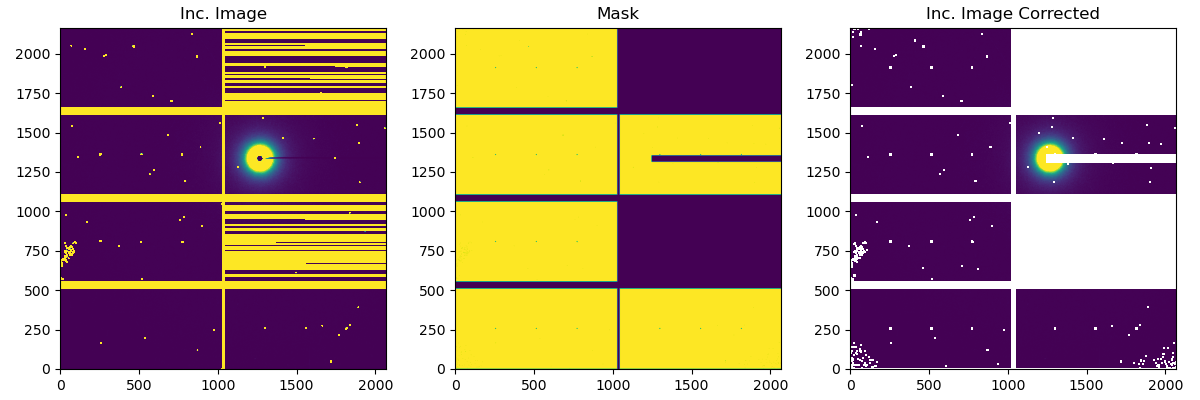

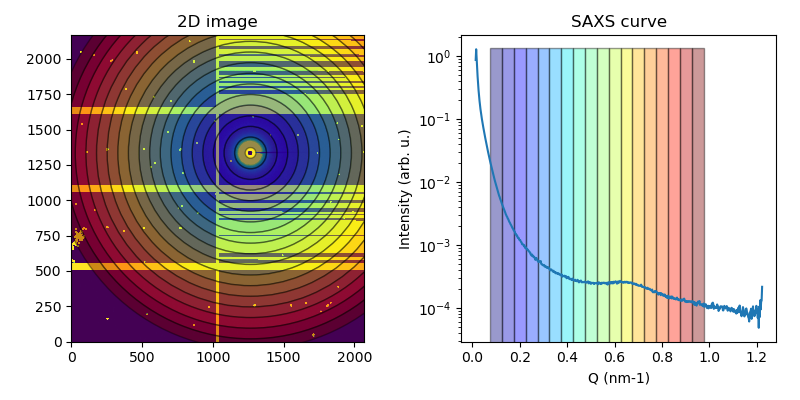

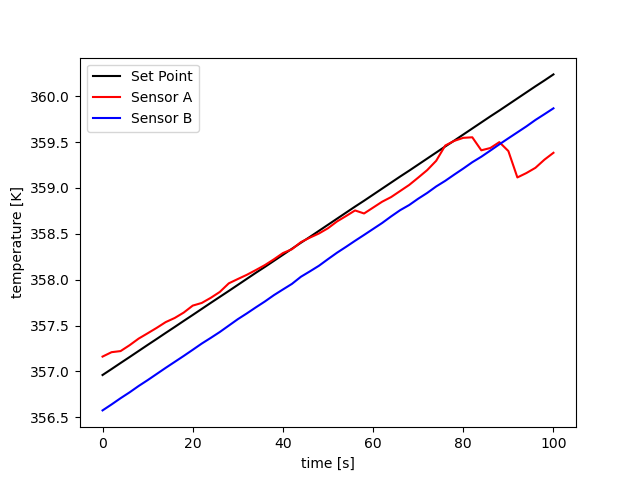

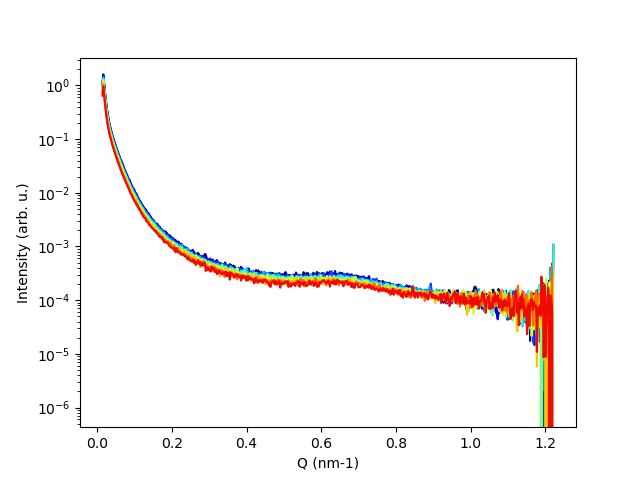

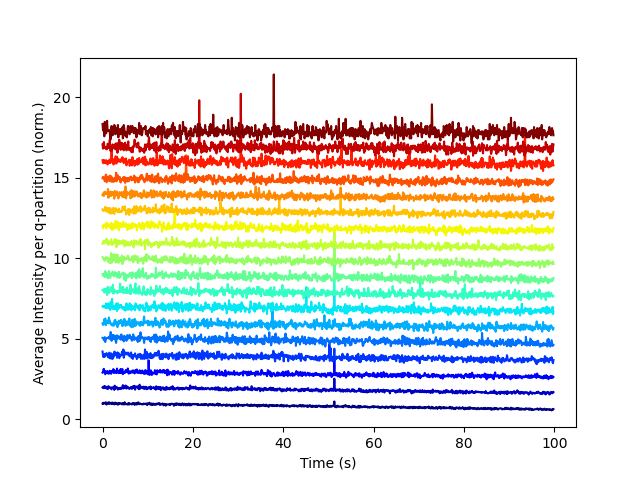

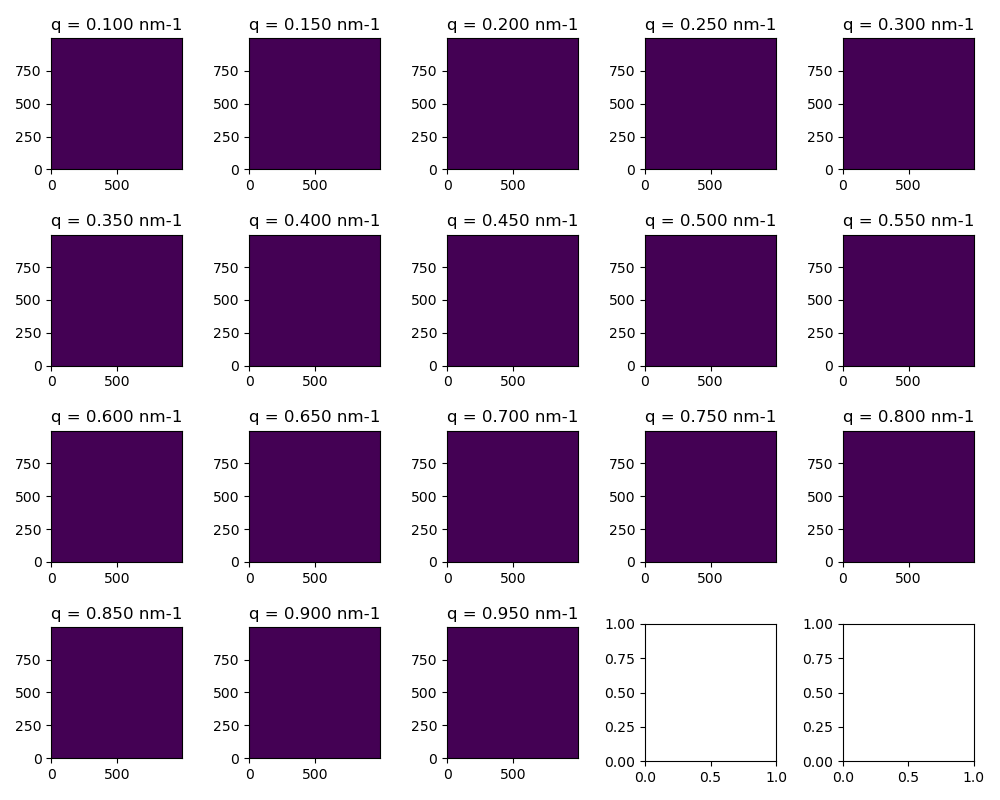

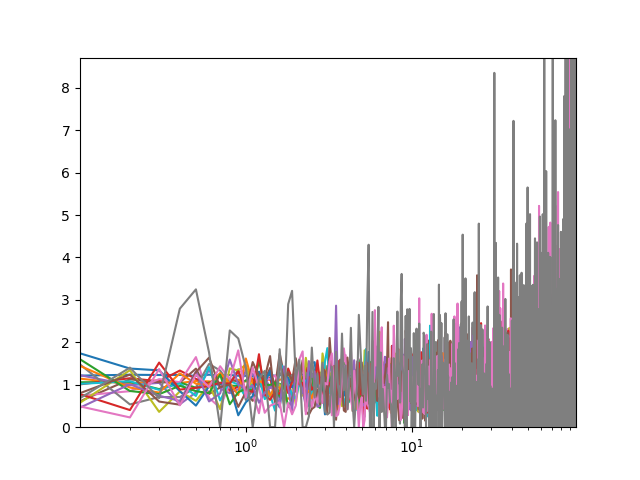

Took 70.933 s for processing.


In [10]:
for scan in scans:
    time_start = time.time()
    # create instances
    scan = autoXPCS.Scan(sample=sample, detector=detector, scan_number=scan, skip_frames_start=skip_frames_start, experimental_parameters=experimental_parameters)
    scan.provide_mask(mask=mask)
    
    # update experimental parameters
    experimental_parameters.update_all_experimental_parameters(scan)

    # load raw data
    if scan.exists_raw_data():
        scan.load_raw_data()

    # create instance of the processing results
    processing_results = autoXPCS.Processing_Results(scan=scan, directory_general_saving=dir_general_saving) # optional: overwrite=False (default)

    # process
    incoh_img, incoh_img_cor = scan.process_incoherent_image(show_figure=show_processing_figures, plot_max = plot_max_incoherent_img)
    processing_results.results_incoherent_img = incoh_img
    processing_results.results_incoherent_img_cor = incoh_img_cor

    # calculate SAXS results
    results_SAXS = scan.process_SAXS(precision_SAXS=precision_SAXS)
    save_SAXS_slices=False
    if average_over_frames_SAXS != 0:
        results_SAXS_slices = scan.process_SAXS_slices(average_over_frames_SAXS, precision_SAXS=precision_SAXS)
        save_SAXS_slices=True
        processing_results.add_saxs_slices_results(results_SAXS_slices)
    processing_results.add_saxs_results(results_SAXS)
    
    # update q-partitions
    q_partitions.create_q_partitions_from_q_rings(q_rings=q_rings, scan=scan)
    q_partitions.define_colors_q_partitions()
    processing_results.q_partitions_figure = q_partitions.show_q_ring_partitions(scan=scan, results_SAXS=results_SAXS, show_figure=show_processing_figures, vmax=plot_max_incoherent_img)
        
    # calculate TTCs
    results_TTC = scan.calculate_ttcs(q_partitions=q_partitions)
    results_TTC.create_delay_times(experimental_parameters=experimental_parameters)

    # calculate g2s
    results_TTC.calculate_g2s_diagonal_cuts()
    processing_results.add_ttc_results(results_TTC)

    # get Temperature data
    if process_temp_data == True:
        scan.get_start_end_time()
        scan.update_end_time() #use if end time in bachinfo is the same as the start time
        temp_data = scan.get_temp_file_data(path_to_temp_file)
        processing_results.add_temp_data(temp_data)
        temp_data.plot_temp_data()

    # create output
    if save_results == True:
        processing_results.generate_output(saxs_slices=save_SAXS_slices, temp_data=process_temp_data)
        processing_results.write_output_summary()
    
    if show_processing_figures:
        if average_over_frames_SAXS != 0:
            results_SAXS_slices.plot_SAXS_curves()
        else:
            results_SAXS.plot_SAXS_curve()
        results_TTC.plot_intensity_variation(experimental_parameters=experimental_parameters)
        results_TTC.plot_ttcs()
        results_TTC.plot_g2s()

    # clean up for next scan (save memory)
    del results_SAXS, results_TTC, processing_results, scan
    gc.collect()
    time_end = time.time()
    print(f'Took {time_end - time_start:.3f} s for processing.')